In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings

%store -r varnames

for name in varnames:
    %store -r $name

In [2]:
# Define stat model
# params = list of length 6
# mcvals = dict of length 4 (corresponding to region),
#          each value is a dict of length 6 (corresponding to data type),
#          each value is a np array corresponding to the hist mc data
# dvals = dict of length 4 (corresponding to region),
#         each value is a np array corresponding to the hist real data
def nll(params):
    a_ttg, a_wg, a_zg, a_other, a_misid, a_np, theta_ttg = params

    # enforce positivity
    if a_ttg < 0 or a_wg <= 0 or a_zg <= 0 or a_other <= 0 or a_misid <= 0 or a_np <= 0:
        return np.inf

    kappa_ttg = 1.05 # 10% ln(N) uncertainty

    # define prediction
    preds_all_regions = []
    for key in mcvals.keys():
        preds = (a_ttg * (kappa_ttg ** theta_ttg) * mcvals[key]["ttgamma"]
            + a_wg * mcvals[key]["WG"]
            + a_zg * mcvals[key]["ZG"]
            + a_other * mcvals[key]["other"]
            + a_misid * mcvals[key]["MisID"]
            + a_np * mcvals[key]["NonPrompt"])*1.
        if np.any(preds <= 0):
            return np.inf
        preds_all_regions.append(preds)
    # define data
    data_all_regions = []
    for key in dvals.keys():
        data_all_regions.append(
            dvals[key]
        )
        
    nll = []
    for preds, data in zip(preds_all_regions, data_all_regions):
        nll.append(
            np.sum(preds - data * np.log(preds))
        )
    nll = np.sum(nll) + 0.5*theta_ttg**2
    return nll

In [3]:
x0 = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0]
bounds=[(0, None), (0, None), (0, None), (0, None), (0, None), (0, None), (None, None)]
result = minimize(nll, x0, method="L-BFGS-B", bounds=bounds)
print("Best-fit parameters:", result.x)
print("Minimum NLL:", result.fun)

bf_params = result.x
min_nll = result.fun

bf_params_freq = {
        "ttgamma":   bf_params[0],
        "WG":        bf_params[1],
        "ZG":        bf_params[2],
        "other":     bf_params[3],
        "MisID":     bf_params[4],
        "NonPrompt": bf_params[5],
        "theta":     bf_params[6],
}

%store bf_params_freq

Best-fit parameters: [ 1.04478109  0.8581329   1.05849812  0.97613861  2.5290458   0.90920665
 -0.00388439]
Minimum NLL: -287995.8593799819
Stored 'bf_params_freq' (dict)


[-0.06357506  0.06436464]
95% Confidence Interval = 13.980 - 17.728


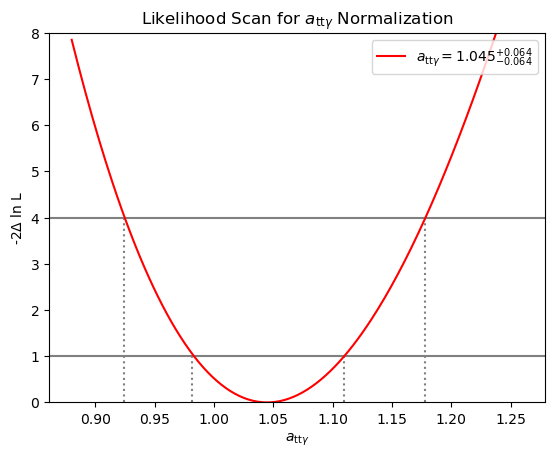

In [7]:
# plot

mu_vals = np.linspace(0.88, 1.26, 200)
profile_nll = []
ymax=8

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    for mu in mu_vals:
    
        def nll_fixed_mu(params):
            a_wg, a_zg, a_other, a_misid, a_np, theta_ttg = params
            return nll([mu, a_wg, a_zg, a_other, a_misid, a_np, theta_ttg])
    
        res = minimize(nll_fixed_mu, [1.0, 1.0, 1.0, 1.0, 1.0, 0.0])
        profile_nll.append(2*res.fun)

profile_nll = np.array(profile_nll)
profile_nll_norm = profile_nll - np.min(profile_nll)

crossings_1 = np.where(np.diff(np.sign(profile_nll_norm - 1.)) != 0)[0]
pairs_1 = [(i, i+1) for i in crossings_1]
mu_crossings_1 = [mu_vals[pairs_1[0][0]], mu_vals[pairs_1[1][0]]]
mu_errs_1 = mu_crossings_1 - bf_params[0]
print(mu_errs_1)

crossings_4 = np.where(np.diff(np.sign(profile_nll_norm - 4.)) != 0)[0]
pairs_4 = [(i, i+1) for i in crossings_4]
mu_crossings_4 = [mu_vals[pairs_4[0][0]], mu_vals[pairs_4[1][0]]]
mu_errs_4 = mu_crossings_4 - bf_params[0]

crossings_95 = np.where(np.diff(np.sign(profile_nll_norm - 3.84)) != 0)[0]
pairs_95 = [(i, i+1) for i in crossings_95]
mu_crossings_95 = [mu_vals[pairs_95[0][0]], mu_vals[pairs_95[1][0]]]
mu_errs_95 = mu_crossings_95 - bf_params[0]

th_sigma = 15.10
print(f"95% Confidence Interval = {mu_crossings_95[0]*th_sigma:.3f} - {mu_crossings_95[1]*th_sigma:.3f}")

plt.clf()
plt.axhline(y=1, c = 'gray')
plt.axhline(y=4, c = 'gray')
plt.axvline(x=mu_crossings_1[0], c = 'gray', ymin=0, ymax=1./ymax, linestyle=":")
plt.axvline(x=mu_crossings_1[1], c = 'gray', ymin=0, ymax=1./ymax, linestyle=":")
plt.axvline(x=mu_crossings_4[0], c = 'gray', ymin=0, ymax=4./ymax, linestyle=":")
plt.axvline(x=mu_crossings_4[1], c = 'gray', ymin=0, ymax=4./ymax, linestyle=":")
plt.plot(mu_vals, profile_nll_norm, c="red", label=r"$a_{\mathrm{tt}\gamma} = 1.045^{+0.064}_{-0.064}$")
plt.legend(loc='upper right')
plt.xlabel(r"$a_{\mathrm{tt}\gamma}$")
plt.ylabel(r"-2$\Delta$ ln L")
plt.ylim(0., ymax)
plt.title(r"Likelihood Scan for $a_{\mathrm{tt}\gamma}$ Normalization")
plt.savefig("./Plots/freq_likelihood.png")
plt.show()


In [5]:
# Find the final measured cross-section with errors

th_sigma = 15.10
errs = mu_errs_1 * th_sigma
sigma = bf_params_freq["ttgamma"] * th_sigma
print(f"mu = {sigma:.3f}^{+errs[1]:.3f}_{-errs[0]:.3f}")

mu = 15.776^0.972_0.960
